In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pylupnt as pnt
from functools import partial

import astropy.units as u
from astropy.coordinates import spherical_to_cartesian, cartesian_to_spherical
from scipy.spatial.distance import cdist

from pylupnt.crater_detection.common.camera import Camera
from pylupnt.crater_detection.common.conics import *
from pylupnt.crater_detection.common.coordinates import ENU_system
from pylupnt.crater_detection.matching.database import load_craters, CraterDatabase
from pylupnt.crater_detection.matching.projective_invariants import CoplanarInvariants
from pylupnt.crater_detection.common.robbins import extract_robbins_dataset

Read blend: "/Users/guillemcv/Development/NavLab/LuPNT/data/surface/Moon.blend"


In [3]:
pnt.utils.find_file("lunar_crater_database_robbins_2018.csv")
datapath = pnt.utils.find_file("lunar_crater_database_robbins_2018.csv")
lat_cat, long_cat, major_cat, minor_cat, psi_cat, crater_id = extract_robbins_dataset(
    load_craters(datapath, diamlims=[2, 30], ellipse_limit=1.4)
)
r_craters_cat = np.array(
    np.array(spherical_to_cartesian(const.RMOON, lat_cat, long_cat))
).T[..., None]
C_craters_cat = conic_matrix(major_cat, minor_cat, psi_cat)

In [4]:
resolution = (256, 256)

# Camera parameters can be derived from RNG
cam_lat, cam_long = map(np.radians, (45., 45.))
cam_alt = 120

cam = ConicProjector.from_coordinates(cam_lat, cam_long, cam_alt, resolution=resolution)

# cam.T = (Rotation.from_matrix(cam.T) * Rotation.from_euler('x', 0, degrees=True)).as_matrix()

dist = cam_alt / np.cos(np.radians(cam.fov[0]/2)*np.sqrt(2) * 1.0)
vicinity = (np.sqrt(np.sum(np.square(r_craters_cat - cam.r), axis=1)) < dist).ravel()
r_craters = r_craters_cat[vicinity]
C_craters = C_craters_cat[vicinity]
A_craters = cam.project_crater_conics(C_craters, r_craters)

crater_centers = cam.project_crater_centers(r_craters)

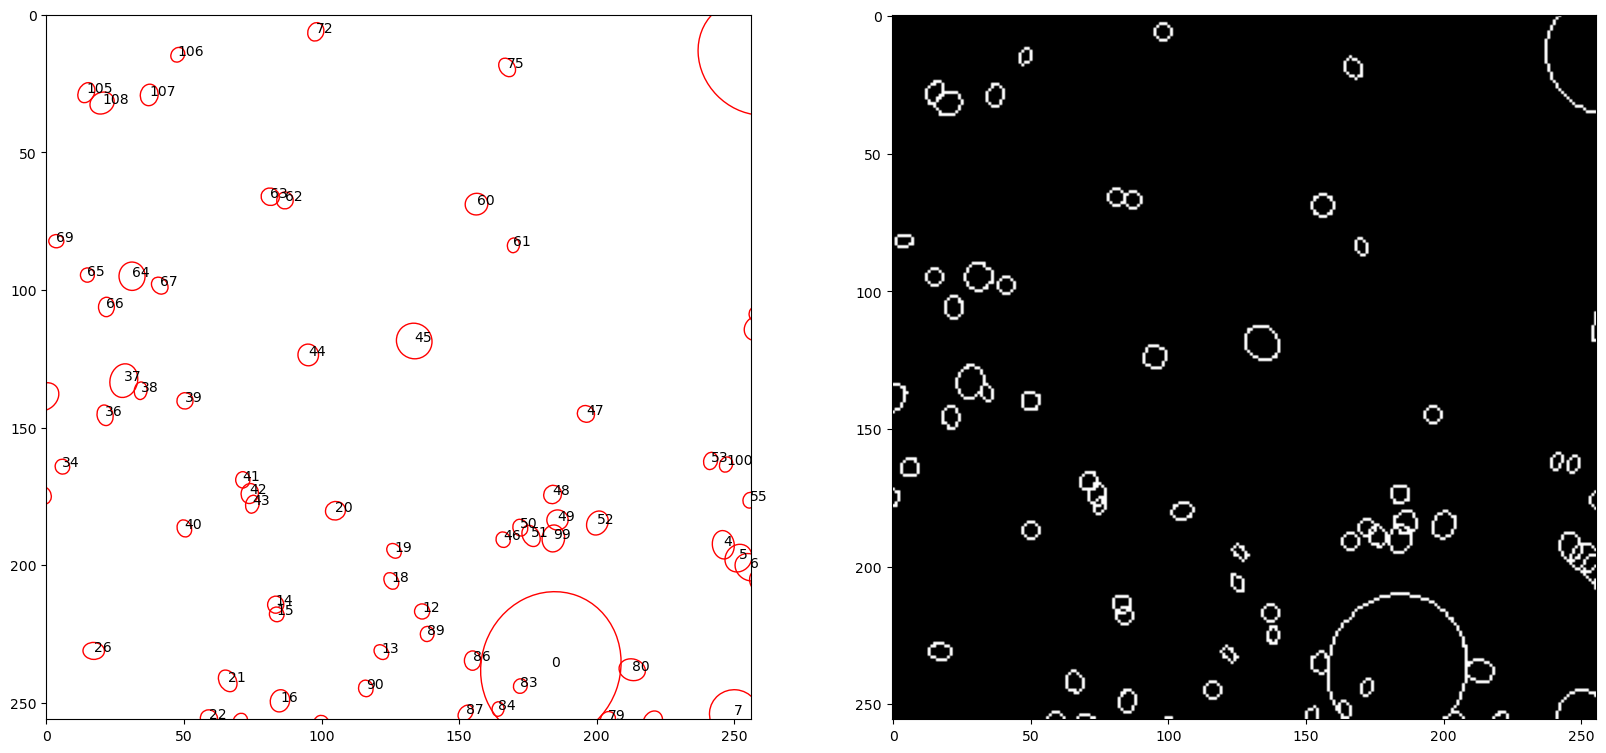

In [5]:
plt.style.use('default')

fig, axes = plt.subplots(1, 2, figsize=(20, 40), subplot_kw={'aspect': 'equal'})

plot_conics(A_craters, resolution=cam.resolution, plot_centers=True, ax=axes[0])
detection_order = np.argsort(cdist(crater_centers, np.array(cam.resolution)[None, :]/2).squeeze())

# plot_conics(A_craters[detection_order], resolution=cam.resolution, plot_centers=True, ax=axes[1])

img_ellipses = generate_mask(A_craters, resolution=resolution, instancing=False)

axes[1].imshow(img_ellipses, cmap='Greys_r')
# fig.savefig('output/crater_mask_example.pdf', bbox_inches = 'tight', pad_inches = 0)

In [1]:
# db = CraterDatabase.from_file("../data/lunar_crater_database_robbins_2018.csv", diamlims=[3, 30], latlims=[20, 70], longlims=[20, 70], radius=100, ellipse_limit=1.4)
db = CraterDatabase(lat_cat[vicinity], long_cat[vicinity], major_cat[vicinity], minor_cat[vicinity], psi_cat[vicinity], radius=500)

NameError: name 'CraterDatabase' is not defined

In [ ]:
sigma_pix = 0.5

n_det = len(A_craters)
# Add noise
major_det, minor_det = ellipse_axes(A_craters)
psi_det = ellipse_angle(A_craters)
r_craters_det = conic_center(A_craters)

major_det += np.random.uniform(-sigma_pix, sigma_pix, size=n_det)
minor_det += np.random.uniform(-sigma_pix, sigma_pix, size=n_det)
psi_det += np.random.normal(scale=(10/180)*np.pi, size=n_det)
r_craters_det += np.random.normal(-sigma_pix, sigma_pix, size=r_craters_det.shape)

A_craters_noisy = conic_matrix(major_det, minor_det, psi_det, *r_craters_det.T)